# Tutorial 7: 3D Dust Mapping

This tutorial demonstrates line-of-sight dust modeling and 3D dust mapping with brutus, including working with Bayestar maps and multi-cloud models.

## Topics Covered

1. **3D dust maps** (Bayestar) and extinction curves
2. **Line-of-sight dust modeling** with stellar posteriors
3. **Smoothing kernels** for dust cloud boundaries
4. **LOS dust fitting** with nested sampling (dynesty)
5. **HEALPix coordinate conversion** with `lb2pix`

## Prerequisites

This tutorial optionally uses:
- `bayestar2019_v1.h5` - Bayestar 3D dust map
- Stellar posterior samples from Tutorial 5

The tutorial will generate synthetic data if these files are not available.

In [1]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import h5py

# Import tutorial utilities
from tutorial_utils import (
    set_plot_style,
    find_brutus_data_file,
    save_figure as save_fig_util,
)

# Set plot style
set_plot_style()
plt.rcParams['figure.figsize'] = (10, 6)

# Create plots directory if needed
plots_dir = Path('plots/tutorial_07')
plots_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name):
    """Helper to save figures."""
    filepath = plots_dir / f"{name}.png"
    fig.savefig(filepath, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filepath}")

## Section 1: Understanding 3D Dust Maps



3D dust maps provide extinction as a function of distance and direction:

- **Bayestar**: Based on Pan-STARRS + 2MASS photometry

- **Resolution**: ~7 arcmin (HEALPix)

- **Distance bins**: 120 bins from 0.06 to 60 kpc

- **Provides**: Mean A(V) and uncertainty



Let's visualize extinction along different sightlines through the Galaxy.

In [2]:
# Try to load Bayestar dust map

dustmap = None

try:

    from brutus.dust.maps import Bayestar



    dustfile = find_brutus_data_file("bayestar2019_v1.h5")

    dustmap = Bayestar(dustfile)

    print("Loaded Bayestar 3D dust map")

    print(f"  NSIDE levels: {dustmap._nside_levels}")

    print(f"  Distance bins: {dustmap._n_distances}")

    print(f"  Distance range: {dustmap._distances[0]:.3f} - {dustmap._distances[-1]:.1f} kpc")

    print(f"  Total pixels: {dustmap._n_pix}")

except (ImportError, FileNotFoundError) as e:

    print("Bayestar dust map not available - will use synthetic model")

    print(f"  Reason: {e}")

Loaded Bayestar 3D dust map
  NSIDE levels: [  64  128  256  512 1024]
  Distance bins: 120
  Distance range: 0.063 - 59.6 kpc
  Total pixels: 4214070


Computing extinction along different sightlines...


  Saved: plots/tutorial_07/dust_sightlines.png


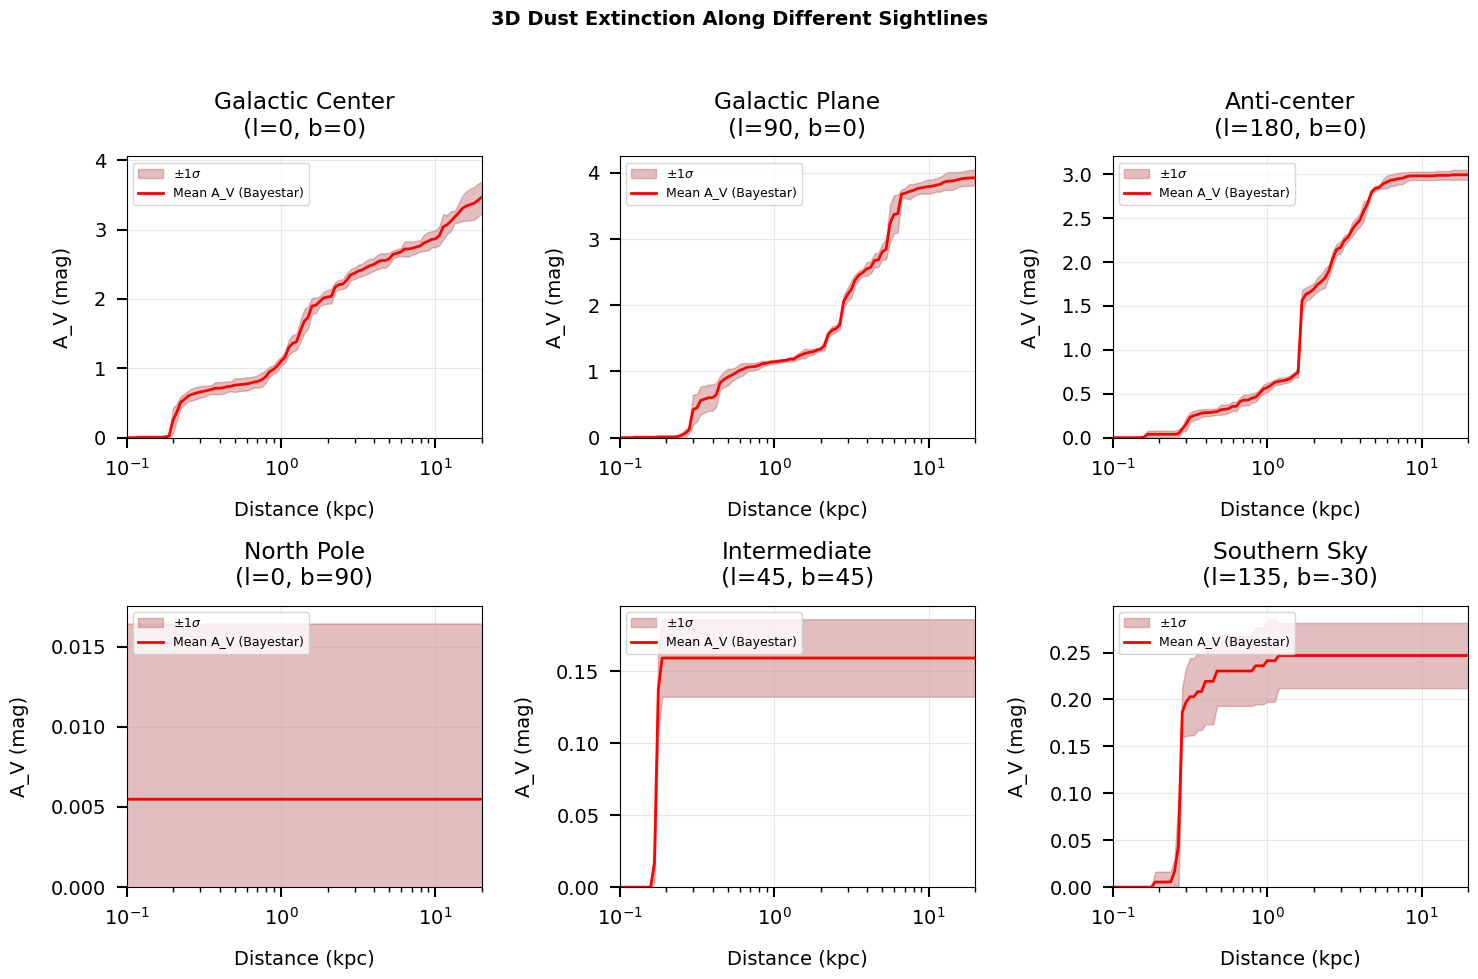


Key observations:
  - Extinction highest toward Galactic center and in plane
  - Minimal extinction at high Galactic latitudes
  - Uncertainty grows with distance


In [3]:
# Visualize dust extinction along different sightlines
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Define test sightlines (l, b in degrees)
sightlines = [
    (0, 0, "Galactic Center"),
    (90, 0, "Galactic Plane"),
    (180, 0, "Anti-center"),
    (0, 90, "North Pole"),
    (45, 45, "Intermediate"),
    (135, -30, "Southern Sky"),
]

print("Computing extinction along different sightlines...")

if dustmap is not None:
    from astropy.coordinates import SkyCoord
    import astropy.units as u

for idx, (l, b, name) in enumerate(sightlines):
    ax = axes[idx // 3, idx % 3]

    source = "Synthetic"
    if dustmap is not None:
        try:
            coord = SkyCoord(l=l * u.deg, b=b * u.deg, frame='galactic')
            dists_map, av_mean, av_std = dustmap.query(coord)

            finite = np.isfinite(av_mean)
            if np.any(finite):
                distances = dists_map[finite]
                av_mean = av_mean[finite]
                av_std = av_std[finite]
                source = "Bayestar"
        except (ValueError, IndexError):
            pass

    if source == "Synthetic":
        distances = np.logspace(np.log10(0.1), np.log10(20), 100)
        av_mean = 0.5 * distances * np.exp(-np.abs(b) / 30)
        av_std = 0.2 * av_mean

    # Plot extinction vs distance
    ax.fill_between(distances, av_mean - av_std, av_mean + av_std,
                    alpha=0.3, color='brown', label=r'$\pm 1\sigma$')
    ax.plot(distances, av_mean, 'r-', lw=2, label=f'Mean A_V ({source})')

    ax.set_xlabel("Distance (kpc)")
    ax.set_ylabel("A_V (mag)")
    ax.set_title(f"{name}\n(l={l}, b={b})")
    ax.set_xscale("log")
    ax.set_xlim(0.1, 20)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle("3D Dust Extinction Along Different Sightlines", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_figure(fig, "dust_sightlines")
plt.show()

print("\nKey observations:")
print("  - Extinction highest toward Galactic center and in plane")
print("  - Minimal extinction at high Galactic latitudes")
print("  - Uncertainty grows with distance")

## Section 2: Line-of-Sight Multi-Cloud Dust Modeling

Real dust distributions often have discrete cloud structures along the line of sight. The `brutus.analysis.los_dust` module provides tools to fit multi-cloud models to stellar extinction measurements, decomposing the cumulative extinction into a foreground component plus discrete cloud jumps at specific distances.

### Input Data

The LOS fitter works with **posterior samples** from BruteForce fits. Each star contributes distance and extinction samples that collectively trace the distance-reddening relation along the sightline.

Let's load stellar posteriors and examine the distance-extinction structure.

In [4]:
# Try to load real stellar posterior samples or generate synthetic ones

print("Preparing stellar posterior samples for LOS dust modeling...\n")



try:

    # Try to find results from Tutorial 5 (Orion field)

    datafile = plots_dir.parent / 'tutorial_05' / 'orion_fits_mist.h5'

    

    if not datafile.exists():

        # Try alternative location

        datafile = find_brutus_data_file("Orion_l204.7_b-19.2_results.h5")

    

    with h5py.File(datafile, 'r') as f:

        # Load distance and extinction samples

        dist_samples = f['samps_dist'][:] if 'samps_dist' in f else None

        av_samples = f['samps_red'][:] if 'samps_red' in f else None

        

        if dist_samples is not None and av_samples is not None:

            print(f"✓ Loaded {len(dist_samples)} stellar posterior samples from file")

            

            # Convert distances to distance modulus for LOS fitting

            dm_samples = 5 * np.log10(dist_samples * 1000) - 5  # kpc to distance modulus

            

            # Only use first 50 stars for demonstration

            dm_samples = dm_samples[:50]

            av_samples = av_samples[:50]

            source = "Real Data"

        else:

            raise ValueError("No distance/extinction samples in file")

            

except (FileNotFoundError, ValueError, KeyError) as e:

    # Generate synthetic samples

    print("Generating synthetic stellar samples...")

    print(f"  (Real data not available: {e})\n")

    

    n_stars = 50

    n_samples = 100

    

    # Create synthetic distance modulus samples

    # Simulate stars at various distances with measurement uncertainties

    true_dm = np.random.uniform(7, 10, n_stars)  # True distance moduli

    dm_error = np.random.uniform(0.1, 0.3, n_stars)  # Uncertainties

    

    dm_samples = np.zeros((n_stars, n_samples))

    for i in range(n_stars):

        dm_samples[i] = np.random.normal(true_dm[i], dm_error[i], n_samples)

    

    # Create synthetic extinction samples (correlated with distance)

    # Simulate a dust cloud at distance modulus ~8.5

    cloud_dm = 8.5

    cloud_width = 0.3

    

    av_samples = np.zeros((n_stars, n_samples))

    for i in range(n_stars):

        # Background extinction

        av_bg = 0.3

        

        # Add cloud extinction for stars behind it

        for j in range(n_samples):

            if dm_samples[i, j] > cloud_dm:

                av_cloud = 1.5 * (1 - np.exp(-(dm_samples[i, j] - cloud_dm) / cloud_width))

                av_samples[i, j] = av_bg + av_cloud + np.random.normal(0, 0.1)

            else:

                av_samples[i, j] = av_bg * (dm_samples[i, j] / cloud_dm) + np.random.normal(0, 0.1)

    

    av_samples = np.maximum(0, av_samples)  # No negative extinction

    source = "Synthetic"



print(f"Using {source} stellar samples:")

print(f"  Stars: {len(dm_samples)}")

print(f"  Samples per star: {dm_samples.shape[1]}")

print(f"  Distance modulus range: [{dm_samples.min():.1f}, {dm_samples.max():.1f}]")

print(f"  A_V range: [{av_samples.min():.2f}, {av_samples.max():.2f}] mag")

Preparing stellar posterior samples for LOS dust modeling...

✓ Loaded 50 stellar posterior samples from file
Using Real Data stellar samples:
  Stars: 50
  Samples per star: 100
  Distance modulus range: [7.2, 17.3]
  A_V range: [0.25, 0.92] mag


  Saved: plots/tutorial_07/stellar_samples.png


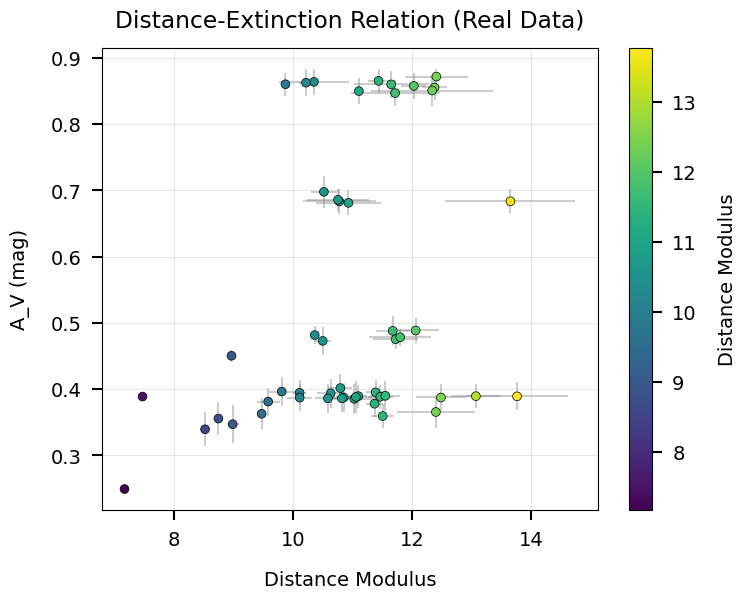

Stars: 50, DM range: [7.2, 13.8]
A_V range: [0.25, 0.87] mag


In [5]:
# Distance-extinction relation from stellar posteriors
fig, ax = plt.subplots(figsize=(8, 6))

# Median values with error bars
dm_median = np.median(dm_samples, axis=1)
dm_std = np.std(dm_samples, axis=1)
av_median = np.median(av_samples, axis=1)
av_std = np.std(av_samples, axis=1)

# Scatter with error bars
ax.errorbar(dm_median, av_median, xerr=dm_std, yerr=av_std,
            fmt='none', ecolor='gray', alpha=0.4, zorder=1)
scatter = ax.scatter(dm_median, av_median, c=dm_median, cmap='viridis',
                     s=40, zorder=5, edgecolor='k', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Distance Modulus')

ax.set_xlabel("Distance Modulus")
ax.set_ylabel("A_V (mag)")
ax.set_title(f"Distance-Extinction Relation ({source})")
ax.grid(True, alpha=0.3)

save_figure(fig, "stellar_samples")
plt.show()

print(f"Stars: {len(dm_median)}, DM range: [{dm_median.min():.1f}, {dm_median.max():.1f}]")
print(f"A_V range: [{av_median.min():.2f}, {av_median.max():.2f}] mag")

## Section 3: Smoothing Kernel Functions

The LOS dust model smooths cloud boundaries using kernel functions. Each kernel takes reddening samples and parameters `(mean, scale)`, returning log-weights:

- **`kernel_tophat(reds, kp)`**: Uniform weight within `[mean - scale, mean + scale]`, zero outside. Sharp cloud edges.
- **`kernel_gauss(reds, kp)`**: Gaussian kernel. Smooth transitions between foreground and cloud (default).
- **`kernel_lorentz(reds, kp)`**: Lorentzian (Cauchy) kernel. Heavy-tailed --- more tolerant of outlying reddening values.

  Saved: plots/tutorial_07/kernel_comparison.png


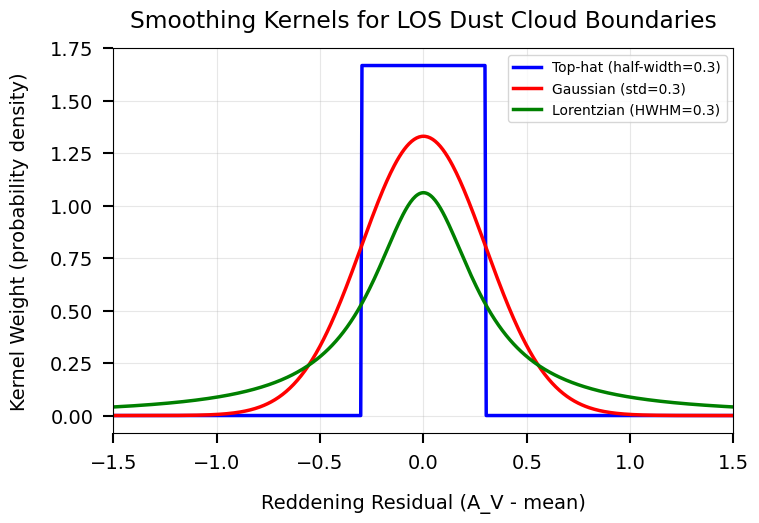

Kernel properties at scale = 0.3:
  Top-hat: Uniform in [-0.3, 0.3], zero outside
  Gaussian: Bell curve, 95% within [-0.6, 0.6]
  Lorentzian: Heavy tails, significant weight beyond +/-0.6


In [6]:
# Compare the three smoothing kernels
from brutus.analysis import kernel_tophat, kernel_gauss, kernel_lorentz

reds = np.linspace(-1.5, 1.5, 500)
scale = 0.3
kp = (0.0, scale)

# Evaluate all three kernels (returns log-weights)
w_tophat = np.exp(kernel_tophat(reds, kp))
w_gauss = np.exp(kernel_gauss(reds, kp))
w_lorentz = np.exp(kernel_lorentz(reds, kp))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(reds, w_tophat, 'b-', lw=2.5, label=f'Top-hat (half-width={scale})')
ax.plot(reds, w_gauss, 'r-', lw=2.5, label=f'Gaussian (std={scale})')
ax.plot(reds, w_lorentz, 'g-', lw=2.5, label=f'Lorentzian (HWHM={scale})')
ax.set_xlabel("Reddening Residual (A_V - mean)")
ax.set_ylabel("Kernel Weight (probability density)")
ax.set_title("Smoothing Kernels for LOS Dust Cloud Boundaries")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-1.5, 1.5)

save_figure(fig, "kernel_comparison")
plt.show()

print(f"Kernel properties at scale = {scale}:")
print(f"  Top-hat: Uniform in [{-scale:.1f}, {scale:.1f}], zero outside")
print(f"  Gaussian: Bell curve, 95% within [{-2*scale:.1f}, {2*scale:.1f}]")
print(f"  Lorentzian: Heavy tails, significant weight beyond +/-{2*scale:.1f}")

## Section 4: Fitting a LOS Dust Model with Dynesty

The LOS fitter uses two key functions designed for nested sampling:

- **`los_clouds_priortransform(u, rlims, dlims)`**: Transforms unit cube draws into physical parameters. For an $n$-cloud model the parameter vector has $2n + 4$ elements: $[p_b, s_{\\text{fore}}, s_{\\text{back}}, A_{V,\\text{fore}}, d_1, A_{V,1}, \\ldots, d_n, A_{V,n}]$
- **`los_clouds_loglike_samples(theta, dsamps, rsamps, ...)`**: Log-likelihood of the cloud model given stellar distance/reddening posterior samples.

For a **1-cloud model** (`ndim=6`), the parameters are:

| Parameter | Meaning |
|-----------|---------|
| $p_b$ | Outlier fraction |
| $s_{\\text{fore}}$ | Foreground smoothing scale |
| $s_{\\text{back}}$ | Background smoothing scale |
| $A_{V,\\text{fore}}$ | Foreground extinction (before cloud) |
| $d_1$ | Cloud distance (distance modulus) |
| $A_{V,1}$ | Total extinction (after cloud) |

Let's run a real nested sampling fit on the Orion stellar posteriors.

In [7]:
# Run LOS dust fit with dynesty
from brutus.analysis import los_clouds_priortransform, los_clouds_loglike_samples
import dynesty
from dynesty.utils import resample_equal

# Set up 1-cloud model (ndim = 6)
ndim = 6

# Determine appropriate bounds from the data
dm_range = (float(dm_samples.min()) - 0.5, float(dm_samples.max()) + 0.5)
av_range = (0.0, max(3.0, float(av_samples.max()) + 0.5))

print(f"LOS fit setup:")
print(f"  Model: 1-cloud ({ndim} parameters)")
print(f"  Stars: {dm_samples.shape[0]}")
print(f"  Samples per star: {dm_samples.shape[1]}")
print(f"  Distance modulus bounds: [{dm_range[0]:.1f}, {dm_range[1]:.1f}]")
print(f"  A_V bounds: [{av_range[0]:.1f}, {av_range[1]:.1f}]")

def prior_transform(u):
    return los_clouds_priortransform(u, rlims=av_range, dlims=dm_range)

def loglike(theta):
    return los_clouds_loglike_samples(
        theta, dm_samples, av_samples,
        kernel='gauss', rlims=av_range, Ndraws=25, monotonic=True
    )

# Run nested sampling (rslice sampler is more efficient for this problem)
import time
print("\nRunning nested sampling...")
t0 = time.time()
sampler = dynesty.NestedSampler(loglike, prior_transform, ndim,
                                nlive=200, sample='rslice')
sampler.run_nested(print_progress=False, maxcall=50000)
results = sampler.results
t_run = time.time() - t0

print(f"  Completed in {t_run:.1f}s")
print(f"  Log-evidence: {results.logz[-1]:.1f} +/- {results.logzerr[-1]:.1f}")
print(f"  Iterations: {results.niter}")

# Extract weighted posterior
weights = np.exp(results.logwt - results.logz[-1])
weights /= weights.sum()
posterior = resample_equal(results.samples, weights)

param_names = ['P_b', 's_fore', 's_back', 'A_V_fore', 'd_cloud (DM)', 'A_V_total']
print(f"\nPosterior summary (median [16th, 84th]):")
for i, name in enumerate(param_names):
    med = np.median(posterior[:, i])
    lo, hi = np.percentile(posterior[:, i], [16, 84])
    print(f"  {name:20s}: {med:.3f}  [{lo:.3f}, {hi:.3f}]")

# Convert cloud distance to kpc
dm_cloud = np.median(posterior[:, 4])
dist_kpc = 10**((dm_cloud + 5) / 5) / 1000
delta_av = np.median(posterior[:, 5] - posterior[:, 3])
print(f"\nCloud properties:")
print(f"  Distance: {dist_kpc:.2f} kpc (DM = {dm_cloud:.1f})")
print(f"  Foreground A_V: {np.median(posterior[:, 3]):.3f} mag")
print(f"  Extinction jump at cloud: {delta_av:.3f} mag")

LOS fit setup:
  Model: 1-cloud (6 parameters)
  Stars: 50
  Samples per star: 100
  Distance modulus bounds: [6.7, 17.8]
  A_V bounds: [0.0, 3.0]

Running nested sampling...


  Completed in 27.2s
  Log-evidence: 4.1 +/- 1.7
  Iterations: 1497

Posterior summary (median [16th, 84th]):
  P_b                 : 0.020  [0.012, 0.035]
  s_fore              : 0.042  [0.036, 0.054]
  s_back              : 0.060  [0.055, 0.068]
  A_V_fore            : 0.372  [0.358, 0.438]
  d_cloud (DM)        : 9.660  [9.464, 9.925]
  A_V_total           : 0.556  [0.535, 0.605]

Cloud properties:
  Distance: 0.85 kpc (DM = 9.7)
  Foreground A_V: 0.372 mag
  Extinction jump at cloud: 0.186 mag


  Saved: plots/tutorial_07/los_dust_fit.png


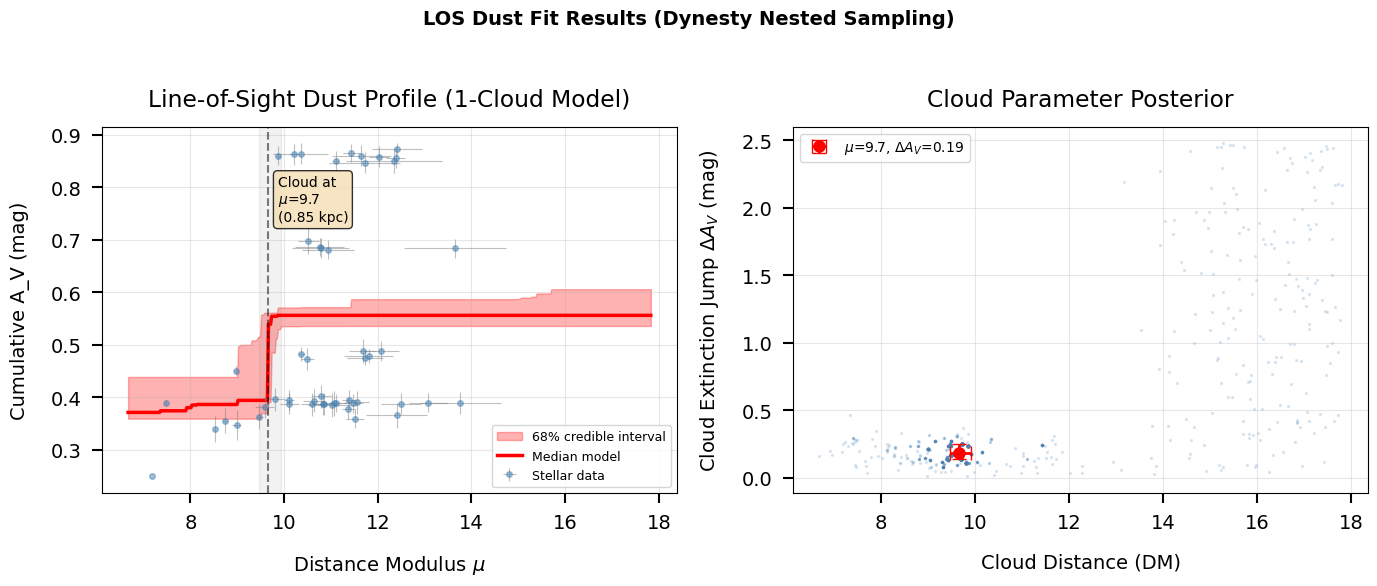

LOS dust fit visualization complete


In [8]:
# Visualize the LOS dust fit results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Fitted LOS profile with posterior uncertainty ---
ax = axes[0]

# Distance modulus grid for plotting the step function
dm_grid = np.linspace(dm_range[0], dm_range[1], 500)

# Compute model profiles from posterior samples
n_plot = min(200, len(posterior))
plot_idx = np.random.choice(len(posterior), n_plot, replace=False)
profiles = np.zeros((n_plot, len(dm_grid)))

for j, k in enumerate(plot_idx):
    av_fore_j = posterior[k, 3]
    d_cloud_j = posterior[k, 4]
    av_total_j = posterior[k, 5]
    profile = np.where(dm_grid < d_cloud_j, av_fore_j, av_total_j)
    profiles[j] = profile

# Median and credible interval
profile_med = np.median(profiles, axis=0)
profile_lo = np.percentile(profiles, 16, axis=0)
profile_hi = np.percentile(profiles, 84, axis=0)

# Plot model band
ax.fill_between(dm_grid, profile_lo, profile_hi, alpha=0.3, color='red',
                label='68% credible interval')
ax.plot(dm_grid, profile_med, 'r-', lw=2.5, label='Median model')

# Overlay stellar data
ax.errorbar(dm_median, av_median, xerr=dm_std, yerr=av_std,
            fmt='o', markersize=4, alpha=0.5, color='steelblue',
            ecolor='gray', elinewidth=0.8, label='Stellar data')

# Mark cloud location
dm_cloud_med = np.median(posterior[:, 4])
dm_cloud_lo, dm_cloud_hi = np.percentile(posterior[:, 4], [16, 84])
ax.axvline(dm_cloud_med, color='k', ls='--', alpha=0.5, lw=1.5)
ax.axvspan(dm_cloud_lo, dm_cloud_hi, alpha=0.1, color='gray')

dist_kpc_med = 10**((dm_cloud_med + 5) / 5) / 1000
ax.text(dm_cloud_med + 0.2, ax.get_ylim()[1] * 0.9,
        f'Cloud at\n$\mu$={dm_cloud_med:.1f}\n({dist_kpc_med:.2f} kpc)',
        fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel("Distance Modulus $\mu$")
ax.set_ylabel("Cumulative A_V (mag)")
ax.set_title("Line-of-Sight Dust Profile (1-Cloud Model)")
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

# --- Panel 2: Cloud parameter posteriors ---
ax = axes[1]

# 2D posterior for cloud distance vs extinction jump
delta_av = posterior[:, 5] - posterior[:, 3]  # Total - foreground = cloud jump
sc = ax.scatter(posterior[:, 4], delta_av, s=2, alpha=0.15, c='steelblue')

# Median + error bars
med_d = np.median(posterior[:, 4])
med_dav = np.median(delta_av)
lo_d, hi_d = np.percentile(posterior[:, 4], [16, 84])
lo_dav, hi_dav = np.percentile(delta_av, [16, 84])

ax.errorbar(med_d, med_dav,
            xerr=[[med_d - lo_d], [hi_d - med_d]],
            yerr=[[med_dav - lo_dav], [hi_dav - med_dav]],
            fmt='o', color='red', markersize=8, capsize=5, lw=2,
            label=f'$\mu$={med_d:.1f}, $\Delta A_V$={med_dav:.2f}')

ax.set_xlabel("Cloud Distance (DM)")
ax.set_ylabel("Cloud Extinction Jump $\Delta A_V$ (mag)")
ax.set_title("Cloud Parameter Posterior")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle("LOS Dust Fit Results (Dynesty Nested Sampling)",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_figure(fig, "los_dust_fit")
plt.show()

print("LOS dust fit visualization complete")

## Section 5: HEALPix Coordinate Conversion with lb2pix

The `lb2pix` function converts Galactic coordinates (l, b) to HEALPix pixel indices, which is fundamental for spatially organizing dust measurements across the sky. This function wraps healpy's coordinate conversion with built-in validation and supports both nested and ring pixel ordering.

Key parameters:
- **nside**: HEALPix resolution parameter (must be a power of 2). Higher nside = finer pixels.
- **l, b**: Galactic longitude and latitude in degrees.
- **nest**: If True (default), use nested ordering; if False, use ring ordering.

The total number of pixels at a given nside is $12 \times \text{nside}^2$.

In [9]:
# Demonstrate lb2pix: converting Galactic (l, b) to HEALPix pixel indices
from brutus.dust import lb2pix

# --- Single coordinate conversion ---
print("=== Single Coordinate Conversion ===")
pix = lb2pix(nside=64, l=0.0, b=0.0)
print(f"  Galactic Center (l=0, b=0) -> pixel {pix}  (nside=64)")

pix_ngp = lb2pix(nside=64, l=0.0, b=90.0)
print(f"  North Galactic Pole (l=0, b=90) -> pixel {pix_ngp}  (nside=64)")

pix_ac = lb2pix(nside=64, l=180.0, b=0.0)
print(f"  Anti-center (l=180, b=0) -> pixel {pix_ac}  (nside=64)")

# --- Array of coordinates ---
print("\n=== Batch Coordinate Conversion ===")
l_arr = np.array([0.0, 45.0, 90.0, 135.0, 180.0, 270.0])
b_arr = np.array([0.0, 30.0, -30.0, 60.0, -60.0, 0.0])
pix_arr = lb2pix(nside=64, l=l_arr, b=b_arr)

print(f"  {'l (deg)':>10s}  {'b (deg)':>10s}  {'pixel (nside=64)':>18s}")
print(f"  {'-'*10}  {'-'*10}  {'-'*18}")
for l_val, b_val, p in zip(l_arr, b_arr, pix_arr):
    print(f"  {l_val:10.1f}  {b_val:10.1f}  {p:18d}")

# --- Resolution comparison ---
print("\n=== Resolution Comparison (same coordinate at different nside) ===")
l_test, b_test = 120.0, -15.0
nside_values = [8, 16, 32, 64, 128, 256, 512, 1024]

print(f"  Coordinate: l={l_test}, b={b_test}")
print(f"  {'nside':>8s}  {'npix_total':>12s}  {'pixel_index':>14s}  {'approx_res (arcmin)':>20s}")
print(f"  {'-'*8}  {'-'*12}  {'-'*14}  {'-'*20}")
for ns in nside_values:
    npix_total = 12 * ns**2
    p = lb2pix(nside=ns, l=l_test, b=b_test)
    res_arcmin = np.sqrt(4 * np.pi * (180 / np.pi * 60)**2 / npix_total)
    print(f"  {ns:8d}  {npix_total:12d}  {p:14d}  {res_arcmin:20.2f}")

# --- Nested vs ring ordering ---
print("\n=== Nested vs Ring Ordering ===")
l_demo, b_demo = 45.0, 10.0
pix_nest = lb2pix(nside=64, l=l_demo, b=b_demo, nest=True)
pix_ring = lb2pix(nside=64, l=l_demo, b=b_demo, nest=False)
print(f"  (l={l_demo}, b={b_demo}) at nside=64:")
print(f"    Nested ordering: pixel {pix_nest}")
print(f"    Ring ordering:   pixel {pix_ring}")

print("\nlb2pix is the core building block for mapping stellar fits onto a HEALPix grid.")

=== Single Coordinate Conversion ===
  Galactic Center (l=0, b=0) -> pixel 19456  (nside=64)
  North Galactic Pole (l=0, b=90) -> pixel 4095  (nside=64)
  Anti-center (l=180, b=0) -> pixel 26282  (nside=64)

=== Batch Coordinate Conversion ===
     l (deg)     b (deg)    pixel (nside=64)
  ----------  ----------  ------------------
         0.0         0.0               19456
        45.0        30.0                 960
        90.0       -30.0               20672
       135.0        60.0                7375
       180.0       -60.0               43136
       270.0         0.0               30378

=== Resolution Comparison (same coordinate at different nside) ===
  Coordinate: l=120.0, b=-15.0
     nside    npix_total     pixel_index   approx_res (arcmin)
  --------  ------------  --------------  --------------------
         8           768             635                439.74
        16          3072            2542                219.87
        32         12288           10170     

## Summary and Key Takeaways

This tutorial has demonstrated 3D dust mapping with brutus:

### Key Concepts

1. **3D Dust Maps** (`brutus.dust.maps.Bayestar`)
   - Bayestar provides A(V) vs distance from Pan-STARRS + 2MASS
   - Resolution ~7 arcmin (HEALPix), 120 distance bins from 0.06--60 kpc
   - Query with `SkyCoord` objects; returns `(distances, av_mean, av_std)`

2. **LOS Dust Modeling** (`brutus.analysis.los_dust`)
   - Multi-cloud models fit discrete dust structures along the line of sight
   - Three smoothing kernels: Gaussian (default), Lorentzian, top-hat
   - Prior transform + log-likelihood designed for nested sampling (dynesty)
   - Compare evidence (logZ) across models with different numbers of clouds

3. **HEALPix Coordinates** (`brutus.dust.lb2pix`)
   - Converts Galactic (l, b) to HEALPix pixel indices
   - Supports nested/ring ordering and array inputs

### Next Steps

- **Tutorial 8**: Photometric Calibration
- Try fitting 2-cloud and 3-cloud models and comparing evidence
- Apply LOS fitting across multiple sightlines for a 3D dust map

In [10]:
print("Tutorial 7 Complete!")
print("=" * 60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")

Tutorial 7 Complete!

Generated plots:
  - dust_sightlines.png
  - kernel_comparison.png
  - los_dust_fit.png
  - stellar_samples.png
